# Portable Physical-System Records


**Purpose.** Inspect how portable model specifications preserve physical sites, local degrees of freedom, basis ordering, and interaction semantics.


**Lattice model.** The notebook compares XXZ, Fermi-Hubbard, and Kitaev BdG specifications. Each `ModelSpec` can carry `local_degrees`, `basis_mappings`, and `interactions` so the physical model remains interpretable after JSON or matrix interchange.


**Variables.** `local_degrees` describes spins, orbitals, fermionic modes, or Nambu components; `basis_mappings` records tensor-factor, mode, or single-particle ordering; `interactions` stores operators and coefficients; `model.hamiltonian()` constructs the corresponding matrix.


**Outputs.** The notebook prints portable-record counts and plots interaction graphs directly from the model specifications.


In [1]:
import matplotlib.pyplot as plt

from quantum_lattice_models import ModelSpec, create_model_spec
from quantum_lattice_models.plotting import plot_interaction_graph

In [2]:
models = {
    "XXZ": create_model_spec(
        "xxz_chain",
        parameters={"n_sites": 4, "coupling": 1.0, "anisotropy": 0.6, "field": 0.2},
    ),
    "Fermi-Hubbard": create_model_spec(
        "fermi_hubbard_chain",
        parameters={"n_sites": 3, "hopping": 0.7, "interaction": 2.0},
    ),
    "Kitaev BdG": create_model_spec(
        "kitaev_chain_bdg",
        parameters={"n_sites": 3, "hopping": 1.0, "pairing": 0.5},
    ),
}

print("model | local degrees | mappings | interactions | matrix shape")
print("--- | --- | --- | --- | ---")
for label, model in models.items():
    print(
        f"{label} | {len(model.local_degrees)} | {len(model.basis_mappings)} | "
        f"{len(model.interactions)} | {model.hamiltonian().shape}"
    )

model | local degrees | mappings | interactions | matrix shape
--- | --- | --- | --- | ---
XXZ | 4 | 4 | 13 | (16, 16)
Fermi-Hubbard | 6 | 6 | 13 | (64, 64)
Kitaev BdG | 6 | 6 | 14 | (6, 6)


In [3]:
for label, model in models.items():
    kinds = [degree.kind for degree in model.local_degrees]
    roles = [mapping.role for mapping in model.basis_mappings]
    operators = sorted({term.operators for term in model.interactions})
    print(label)
    print(f"  degree kinds: {kinds}")
    print(f"  mapping roles: {roles}")
    print(f"  operator signatures: {operators}")

XXZ
  degree kinds: ['spin', 'spin', 'spin', 'spin']
  mapping roles: ['tensor_factor', 'tensor_factor', 'tensor_factor', 'tensor_factor']
  operator signatures: [('X', 'X'), ('Y', 'Y'), ('Z',), ('Z', 'Z')]
Fermi-Hubbard
  degree kinds: ['fermion', 'fermion', 'fermion', 'fermion', 'fermion', 'fermion']
  mapping roles: ['mode', 'mode', 'mode', 'mode', 'mode', 'mode']
  operator signatures: [('create', 'annihilate'), ('number',), ('number', 'number')]
Kitaev BdG
  degree kinds: ['nambu', 'nambu', 'nambu', 'nambu', 'nambu', 'nambu']
  mapping roles: ['single_particle_state', 'single_particle_state', 'single_particle_state', 'single_particle_state', 'single_particle_state', 'single_particle_state']
  operator signatures: [('hole',), ('hole', 'hole'), ('particle',), ('particle', 'hole'), ('particle', 'particle')]


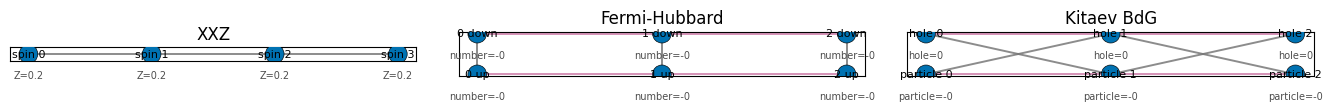

In [4]:
figure, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
for ax, (label, model) in zip(axes, models.items(), strict=True):
    plot_interaction_graph(model, ax=ax, show_coefficients=False)
    ax.set_title(label)
figure.tight_layout()

Spin mappings identify local tensor factors, Fermi-Hubbard mappings identify ordered occupation modes, and BdG mappings identify direct particle/hole matrix-state indices. These meanings remain distinct even though all three use the same portable record types.

In [5]:
original = models["Kitaev BdG"]
restored = ModelSpec.from_dict(original.to_dict())
print("Kitaev BdG JSON round trip")
print(f"  specifications equal: {restored == original}")
print(f"  particle/hole order: {[degree.component for degree in restored.local_degrees]}")

Kitaev BdG JSON round trip
  specifications equal: True
  particle/hole order: ['particle', 'particle', 'particle', 'hole', 'hole', 'hole']
